## Costumer Segmentation (Clustering)

> https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering

     Autora do Notebook: Isabella Heder 


Este projeto tem como objetivo analisar o comportamento e o perfil de clientes a partir de um dataset de marketing, buscando identificar padrões e segmentações que auxiliem na tomada de decisão e na criação de estratégias mais eficientes.

A análise de personalidade de clientes permite entender melhor suas preferências, hábitos de consumo e características demográficas, possibilitando ações mais direcionadas e aumento da efetividade das campanhas.

### Objetivos do Projeto
- Explorar o perfil dos clientes
- Identificar padrões de comportamento de consumo
- Analisar resposta a campanhas de marketing
- Criar segmentações de clientes
- Apoiar estratégias de marketing direcionado

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 300)  
pd.set_option('display.max_colwidth', None)  

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('customer_segmentation.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
df.duplicated().sum()

np.int64(0)

- ``Income`` tem dados nulos
- df não tem dados duplicados


In [4]:
df = df.dropna(subset=['Income'])

#### Dicionário de Dados
| Coluna               | Tipo de Dado | Descrição |
|---------------------|-------------|----------|
| ID                  | Numérico    | Identificador único do cliente |
| Year_Birth          | Numérico    | Ano de nascimento do cliente |
| Education           | Categórico  | Nível de escolaridade |
| Marital_Status      | Categórico  | Estado civil |
| Income              | Numérico    | Renda anual do cliente |
| Kidhome             | Numérico    | Número de crianças no domicílio |
| Teenhome            | Numérico    | Número de adolescentes no domicílio |
| Dt_Customer         | Data        | Data de cadastro do cliente |
| Recency             | Numérico    | Dias desde a última compra |
| MntWines            | Numérico    | Valor gasto em vinhos |
| MntFruits           | Numérico    | Valor gasto em frutas |
| MntMeatProducts     | Numérico    | Valor gasto em carnes |
| MntFishProducts     | Numérico    | Valor gasto em peixes |
| MntSweetProducts    | Numérico    | Valor gasto em doces |
| MntGoldProds        | Numérico    | Valor gasto em produtos premium |
| NumDealsPurchases   | Numérico    | Número de compras com desconto |
| NumWebPurchases     | Numérico    | Número de compras online |
| NumCatalogPurchases | Numérico    | Número de compras via catálogo |
| NumStorePurchases   | Numérico    | Número de compras em loja física |
| NumWebVisitsMonth   | Numérico    | Número de visitas ao site por mês |
| AcceptedCmp1        | Binário     | Aceitou campanha 1 (1 = Sim, 0 = Não) |
| AcceptedCmp2        | Binário     | Aceitou campanha 2 (1 = Sim, 0 = Não) |
| AcceptedCmp3        | Binário     | Aceitou campanha 3 (1 = Sim, 0 = Não) |
| AcceptedCmp4        | Binário     | Aceitou campanha 4 (1 = Sim, 0 = Não) |
| AcceptedCmp5        | Binário     | Aceitou campanha 5 (1 = Sim, 0 = Não) |
| Complain            | Binário     | Cliente fez reclamação (1 = Sim, 0 = Não) |
| Z_CostContact       | Constante   | Custo fixo de contato com cliente |
| Z_Revenue           | Constante   | Receita fixa associada a campanhas |
| Response            | Binário     | Respondeu à campanha atual (1 = Sim, 0 = Não) |


In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


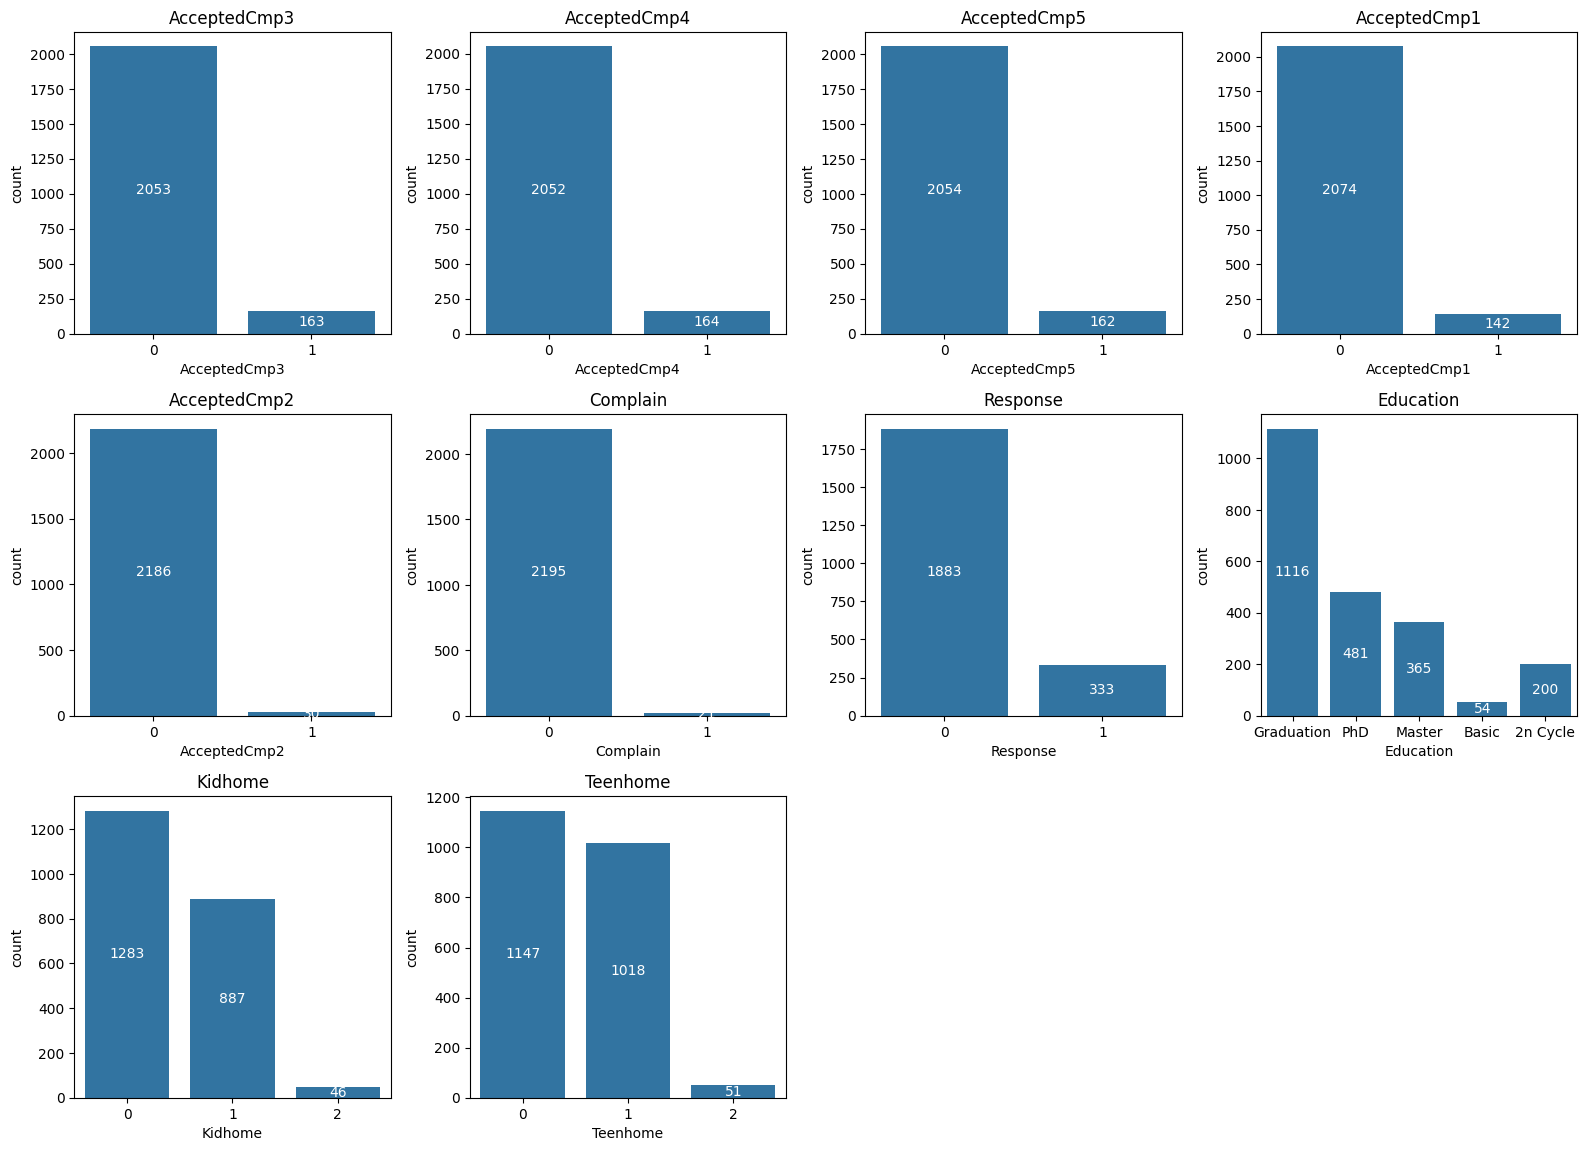

In [6]:
variaveis = [
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain',
    'Response', 'Education', 'Kidhome', 'Teenhome']

plt.figure(figsize=(16, 15))
for i, col in enumerate(variaveis, 1):
    ax = plt.subplot(4, 4, i)
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%d', color='white')

plt.tight_layout()
plt.show()

In [7]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

- Todas as variáveis de aceitamento de campanha apresentam forte desbalanceamento
- A variável alvo (response) apresenta forte desbalanceamento
- A grande maioria dos clientes não fez reclamações
- Base concentrada em nível educacional mais alto
- A maioria dos clientes possuem no máximo 1 filho
- Marital_Status:
    - A maioria dos clientes são casados
    - Existem categorias "estranhas" que podem ser unidas com outras

     Unindo categorias de Estado Civil 

In [8]:
df['estado_civil'] = df['Marital_Status'].replace({
    'Married': 'Com parceiro',
    'Together': 'Com parceiro',
    'Single': 'Alone',
    'Divorced': 'Alone',
    'Widow': 'Alone',
    'Alone': 'Alone',
    'Absurd': 'Alone',
    'YOLO': 'Alone'})

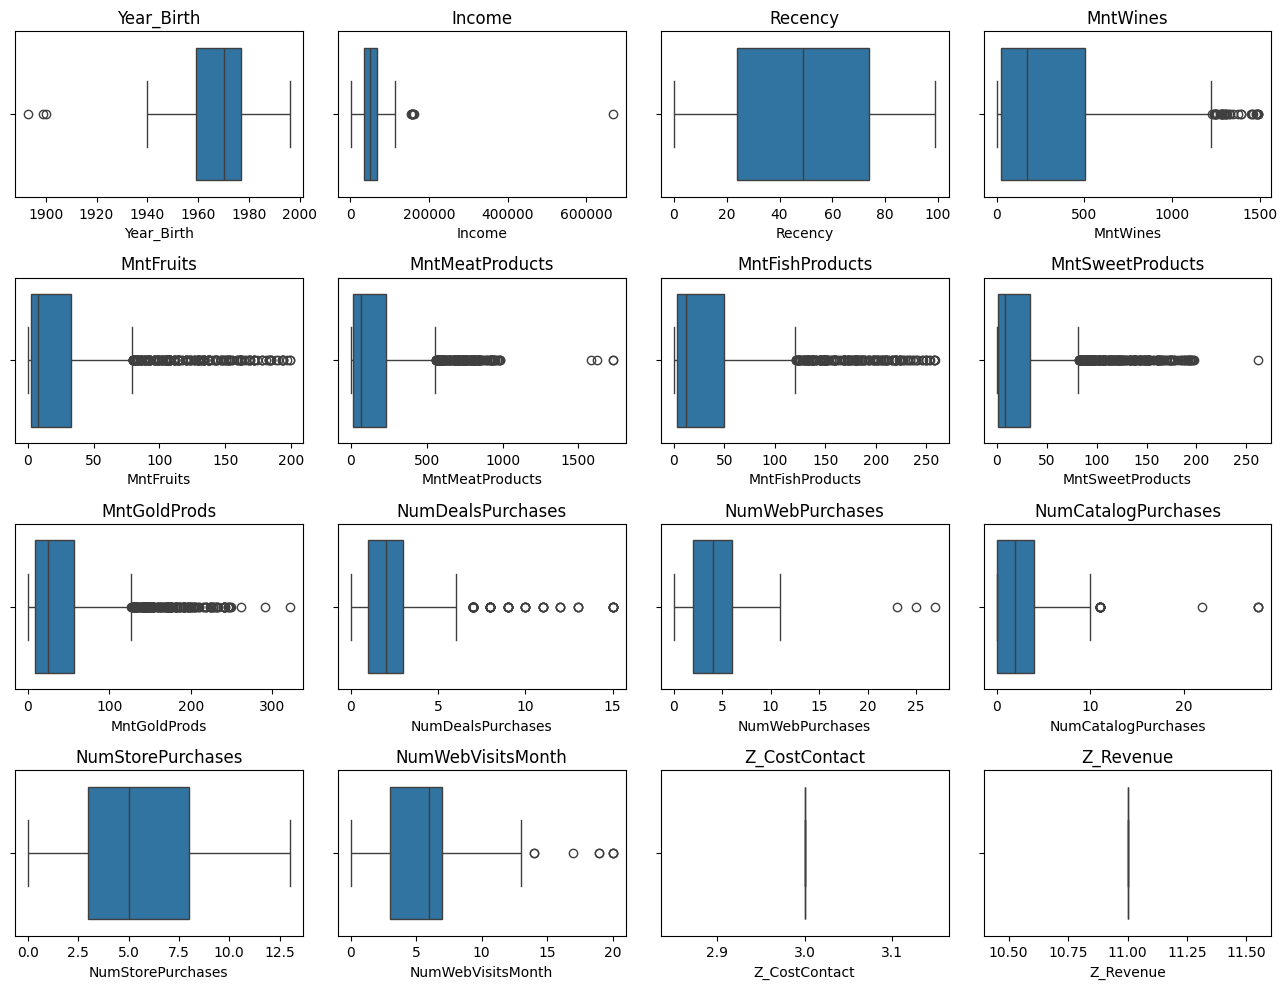

In [9]:
variaveis_continuas = ['Year_Birth', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                       'NumStorePurchases', 'NumWebVisitsMonth', 'Z_CostContact', 'Z_Revenue']
plt.figure(figsize=(13, 10))

for i, col in enumerate(variaveis_continuas):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

- Year_Birth: concentração em 1950-1980, com outliers até antes de 1900
- Income: assimetria à direita, com outlier até +600k
- Recency: distribuição uniforme
- Variáveis de consumo: todas apresentam assimetria à direita (poucos clientes com consumo muito alto)
- NumDealsPurchases: maioria com poucas compras com desconto (alguns clientes com muitas promoções)
- NumWebPurchases / NumCatalogPurchases: concentrado em valores baixos, mas com presença de outliers maiores
- NumStorePurchases: mais equilibrado
- NumWebVisitsMonth: maioria com 3-8 visitas, outliers com até 20 visitas
- Variáveis Z: constantes, não adicionam informação

In [10]:
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

     Tratando Outliers 

In [11]:
def metodo_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lim_inferior = Q1 - 1.5 * IQR
        lim_superior = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lim_inferior, upper=lim_superior)
    
    return df

colunas_outliers = [
    'Income', 'MntWines','MntFruits','MntMeatProducts','MntFishProducts',
    'MntSweetProducts','MntGoldProds',
    'NumDealsPurchases','NumWebPurchases','NumCatalogPurchases',
    'NumStorePurchases','NumWebVisitsMonth']

df = metodo_iqr(df, colunas_outliers)

Após aplicar o método IQR, eu vi que Year_Birth e Income ainda estavam apresentando valores extremos (outliers), por isso, fiz mais um corte

In [12]:
df = df[df['Year_Birth'] > 1920]
df['Income'] = df['Income'].clip(upper=df['Income'].quantile(0.99))

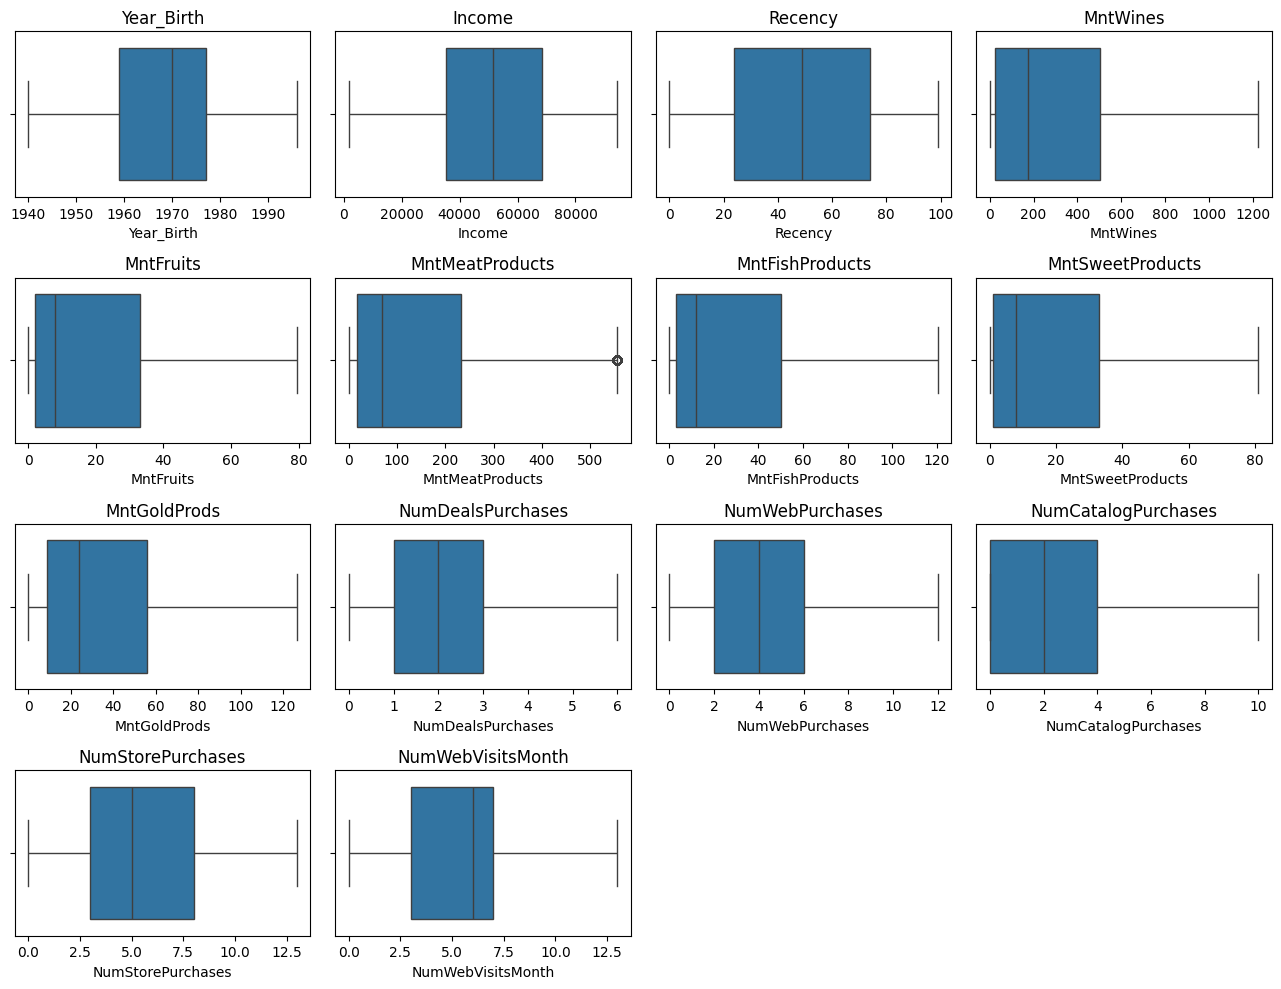

In [13]:
variaveis_continuas = ['Year_Birth', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                       'NumStorePurchases', 'NumWebVisitsMonth']
plt.figure(figsize=(13, 10))

for i, col in enumerate(variaveis_continuas):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

### Feature Engineering

     Total Gasto 

In [14]:
df['total_gasto'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

     Total Compras 

In [15]:
df['total_compras'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

     Total Aceitação de Campanhas 

In [16]:
df['total_campanhas'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1)

## **Clusterização**

In [17]:
features = [
    'Income',
    'Recency',
    'total_gasto',
    'total_compras',
    'NumWebVisitsMonth']

#### **Normalização com RobustScaler**

Método de normalização de dados que usa:
- mediana (median)
- intervalo interquartil (IQR)

Para cada valor ele faz: ``(X - mediana) / IQR``

- ignorando extremos (outliers)
- garante que nenhuma variável domina e que outliers não puxam os clusters

> Mesmo tirando os outliers (o que eu fiz anteriormente), as variáveis ainda tem assimetria (skew)

O método IQR corta outliers

O RobustScaler ajusta a escala

In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[features])

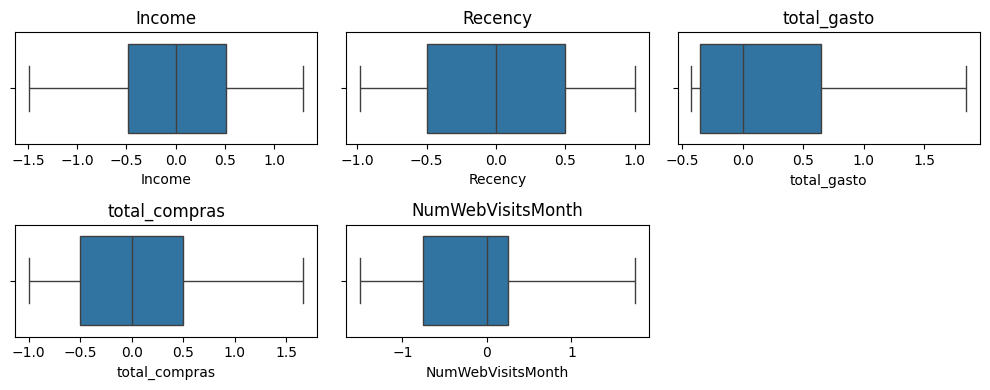

In [19]:
df_scaled = pd.DataFrame(X_scaled, columns=features)

plt.figure(figsize=(10, 4))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=col, data=df_scaled)
    plt.title(col)

plt.tight_layout()
plt.show()

### Método do cotovelo

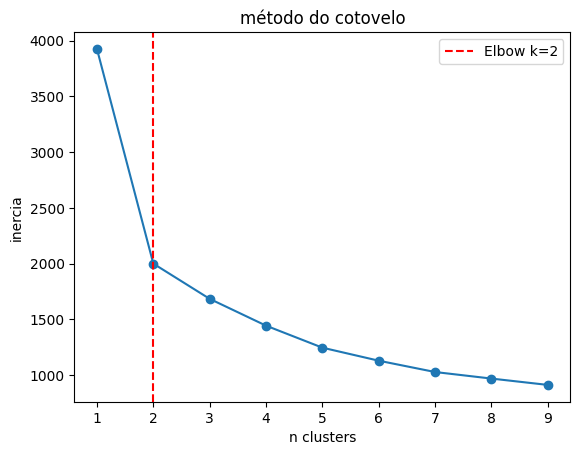

In [20]:
from sklearn.cluster import KMeans
inercia = []

K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

diffs = np.diff(inercia)
diffs2 = np.diff(diffs)

# ponto do cotovelo
elbow_point = np.argmax(np.abs(diffs2)) + 2  # +2 por causa do deslocamento

plt.plot(K, inercia, marker='o')
plt.axvline(elbow_point, color='red', linestyle='--', label=f'Elbow k={elbow_point}')
plt.title('método do cotovelo')
plt.xlabel('n clusters')
plt.ylabel('inercia')
plt.legend()
plt.show()

#### Silhouette Score

In [21]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.418
k=3, silhouette=0.307
k=4, silhouette=0.252
k=5, silhouette=0.262
k=6, silhouette=0.261
k=7, silhouette=0.253
k=8, silhouette=0.250
k=9, silhouette=0.242


### **Escolha do Número de Clusters**

- O método do cotovelo (Elbow) indicou um ponto relevante em k=2
- O Silhouette Score apresentou melhor valor para k=2 (~0.42), indicando melhor separação matemática dos grupos

Porém, essas métricas avaliam apenas a estrutura dos dados e não consideram a utilidade prática dos clusters (para negócio)

Utilizando k=2, a segmentação resultou em dois ``grupos muito amplos``, separando clientes em:
- Baixo valor
- Alto valor
- esses ``grupos são pouco acionáveis do ponto de vista de negócio``, porque não capturam comportamento etc

#### ESCOLHI ``K = 4``:
- Permitiu uma segmentação mais estratégica, separando os clientes em 4 grupos, levando em consideração seu comportamento e engajamento 
- A escolha 4 foi feita priorizando uma segmentação orientada a negócio

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [23]:
df.groupby('cluster')[features].mean()

,Income,Recency,total_gasto,total_compras,NumWebVisitsMonth
cluster,,,,,
0,70687.154021,23.016842,1053.485526,19.065263,3.928421
1,35311.275974,24.225649,147.548093,6.974026,6.642857
2,37737.721498,73.864821,166.601792,7.467427,6.387622
3,70889.167244,73.316929,1116.534203,19.181102,3.657480


Cluster 0 (VIP ATIVO):
- Alta renda
- Alto gasto
- Compram bastante
- Compram recentemente
- Poucas visitas -> decisão rápida
- **Clientes de alto valor**

Cluster 1 (BAIXO VALOR ATIVO):
- Baixa renda
- Baixo gasto
- Ainda ativos
- Visitam bastante -> mas convertem pouco
- **Clientes sensíveis a preço**

Cluster 2 (BAIXO VALOR INATIVO):
- Já compraram no passado
- Estão afastados (recency alto)
- Baixo valor
- Ainda visitam
- **Risco de Churn**

Cluster 3 (VIP INATIVO):
- Mesmo padrão do Cluster 0
- Mas pararam de comprar
- Clientes 'VIP' em risco

_____________
### Visualização dos Clusters com PCA (Principal Component Analysis)

Nesta etapa, foi utilizada a técnica de PCA para reduzir a dimensionalidade dos dados e permitir a visualização dos clusters em duas dimensões.

O dataset, tinha múltiplas variáveis que foram transformadas em 2 componentes principais

Os clusters gerados pelo KMeans foram rotulados a partir do comportamento

In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# adicionar ao dataframe
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

In [25]:
# nomes dos clusters
map_clusters = {
    0: 'VIP Ativo',
    1: 'Baixo Valor Ativo',
    2: 'Baixo Valor Inativo',
    3: 'VIP Inativo'}

df['cluster_nome'] = df['cluster'].map(map_clusters)

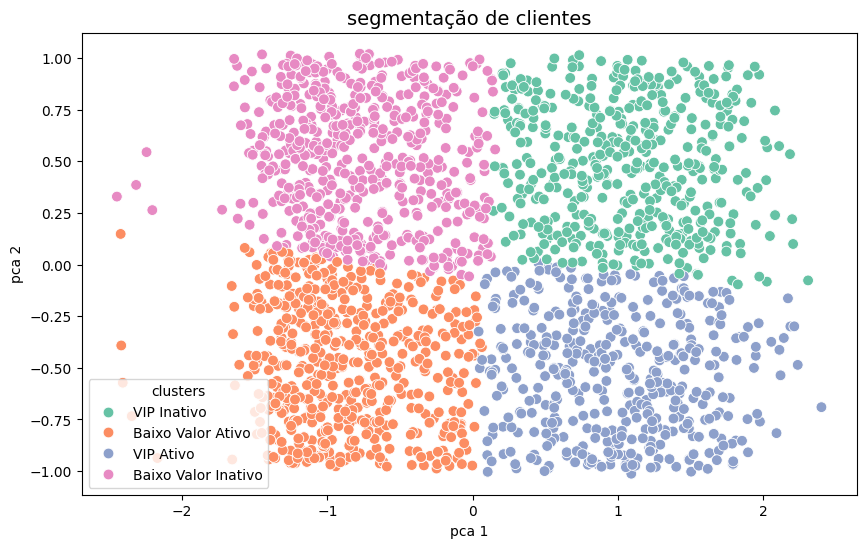

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca1', y='pca2',
                hue='cluster_nome',
                palette='Set2', s=60)

plt.title('segmentação de clientes', fontsize=14)
plt.xlabel('pca 1')
plt.ylabel('pca 2')
plt.legend(title='clusters')
plt.show()

#### Resposta de Clientes à Campanhas 

In [27]:
df.groupby('cluster')['total_campanhas'].mean()

cluster
0    0.536842
1    0.118506
2    0.097720
3    0.535433
Name: total_campanhas, dtype: float64

- Cluster 0 e 3 (VIPs) -> alto engajamento em campanhas
- Cluster 1 e 2 -> quase não respondem campanhas
>
     VIP Inativo (Cluster 3): 
- ainda respondem marketing -> só precisam de estímulo certo
- campanhas personalizadas, ofertas exclusivas e reativação direcionada
>
     Cluster 1 e 2 (baixo valor) 
- não respondem campanhas
- campanhas com eles tem:
    - baixo ROI
    - baixo impacto
- Estratégia: promoções massivas e custos baixos

#### **Aplicação de Negócio**

| Cluster   | Estratégia                           | Ações |
|----------|------------------------------------|-------|
| Cluster 0 (VIP Ativo) | Monetização e crescimento de valor | - Campanhas de upsell (paga mais pelo mesmo) e cross-sell (oferecer complementos na compra)<br>- Ofertas premium exclusivas<br>- Programas de fidelização com benefícios |
| Cluster 1 (Baixo Valor Ativo) | Aquisição e estímulo de consumo | - Promoções de entrada (descontos simples)<br>- Campanhas de baixo custo<br>- Incentivos para aumentar ticket médio |
| Cluster 2 (Baixo Valor Inativo) | Reativação com baixo custo | - Campanhas massivas e automatizadas<br>- Descontos agressivos e simples<br>- Avaliar custo-benefício (baixo ROI esperado) |
| Cluster 3 (VIP Inativo) | Recuperação estratégica (prioridade máxima) | - Campanhas altamente personalizadas<br>- Ofertas exclusivas (VIP)<br>- Contato direto ou abordagem diferenciada<br>- Ações de reengajamento imediato |

Obrigada!
